In [ ]:
exit_county_parentorg_plan_detail_2025_only(1)

In [ ]:
import pandas as pd
exit_df = pd.read_csv("exit_county_parentorg_plan_detail_2025_only(1).csv")

**Organizing and Aligning Column Names**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

def clean_text(s):
    return s.astype(str).str.strip().str.upper()

def clean_num(s):
    return pd.to_numeric(
        s.astype(str).str.replace(r'[$,% ,]', '', regex=True),
        errors='coerce'
    )

def find_col(df, *patterns):
    for c in df.columns:
        low = c.lower()
        if all(p.lower() in low for p in patterns):
            return c
    return None

STATE_COL = "state_abbr"
COUNTY_COL = "county_norm"
PARENT_COL = "parent_org_norm"

CONTRACT_COL = "Contract ID" if "Contract ID" in exit_df.columns else find_col(exit_df, "contract")
PLAN_COL = "Plan ID" if "Plan ID" in exit_df.columns else find_col(exit_df, "plan id")
SEG_COL = "Segment ID" if "Segment ID" in exit_df.columns else find_col(exit_df, "segment")

PLAN_TYPE_COL = "Plan Type" if "Plan Type" in exit_df.columns else find_col(exit_df, "plan", "type")
SNP_TYPE_COL = "SNP Type" if "SNP Type" in exit_df.columns else find_col(exit_df, "snp", "type")

PREMIUM_COL = find_col(exit_df, "part", "c", "premi")
MOOP_COL = find_col(exit_df, "in-network")
STAR_COL = find_col(exit_df, "overall", "star")

print("PLAN_TYPE_COL:", PLAN_TYPE_COL)
print("SNP_TYPE_COL:", SNP_TYPE_COL)
print("PREMIUM_COL:", PREMIUM_COL)
print("MOOP_COL:", MOOP_COL)
print("STAR_COL:", STAR_COL)

PLAN_TYPE_COL: Plan Type
SNP_TYPE_COL: SNP Type
PREMIUM_COL: Part C Premium
MOOP_COL: In-Network Maximum Out-of-Pocket (MOOP) Amount
STAR_COL: Overall Star Rating


**Create Analysis Fields**

In [ ]:
df = exit_df.copy()

df["state_key"] = clean_text(df[STATE_COL])
df["county_key"] = clean_text(df[COUNTY_COL])
df["parent_key"] = clean_text(df[PARENT_COL])

df["county_id"] = df["state_key"] + "|" + df["county_key"]
df["carrier_county_key"] = df["county_id"] + "|" + df["parent_key"]

if CONTRACT_COL and PLAN_COL and SEG_COL:
    df["plan_key"] = (
        df[CONTRACT_COL].astype(str).str.strip() + "_" +
        df[PLAN_COL].astype(str).str.strip() + "_" +
        df[SEG_COL].astype(str).str.strip()
    )
else:
    df["plan_key"] = np.arange(len(df)).astype(str)

if PLAN_TYPE_COL:
    df["plan_type_std"] = clean_text(df[PLAN_TYPE_COL])
else:
    df["plan_type_std"] = np.nan

if SNP_TYPE_COL:
    df["snp_type_std"] = clean_text(df[SNP_TYPE_COL])
else:
    df["snp_type_std"] = np.nan

if PREMIUM_COL:
    df["premium_num"] = clean_num(df[PREMIUM_COL])
else:
    df["premium_num"] = np.nan

if MOOP_COL:
    df["moop_num"] = clean_num(df[MOOP_COL])
else:
    df["moop_num"] = np.nan

if STAR_COL:
    df["star_num"] = clean_num(df[STAR_COL])
else:
    df["star_num"] = np.nan

print(df.shape)
df.head()

(7974, 27)


,state_abbr,county_norm,parent_org_norm,Contract ID,Plan ID,Segment ID,Plan Name,Plan Type,SNP Type,Part D Coverage Indicator,Part C Premium,Monthly Consolidated Premium (Part C + D),In-Network Maximum Out-of-Pocket (MOOP) Amount,Overall Star Rating,County Name,Parent Organization Name,state_key,county_key,parent_key,county_id,carrier_county_key,plan_key,plan_type_std,snp_type_std,premium_num,moop_num,star_num
0,AR,ARKANSAS,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,H2722,2,0,Primewell Classic (HMO-POS),HMO-POS,Not Applicable,Yes,$0.00,$0.00,"$4,500.00",3,Arkansas,Louisiana Health Service & Indemnity Company,AR,ARKANSAS,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,AR|ARKANSAS,AR|ARKANSAS|LOUISIANA HEALTH SERVICE & INDEMNI...,H2722_2_0,HMO-POS,NOT APPLICABLE,0.0,4500.0,3.0
1,AR,ARKANSAS,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,H2722,3,0,Primewell Dual Plus (HMO-POS D-SNP),HMO-POS D-SNP,Dual-Eligible,Yes,$0.00,$20.90,"$9,350.00",3,Arkansas,Louisiana Health Service & Indemnity Company,AR,ARKANSAS,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,AR|ARKANSAS,AR|ARKANSAS|LOUISIANA HEALTH SERVICE & INDEMNI...,H2722_3_0,HMO-POS D-SNP,DUAL-ELIGIBLE,0.0,9350.0,3.0
2,AR,ARKANSAS,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,H2722,4,0,Primewell Reliance (HMO-POS),HMO-POS,Not Applicable,Yes,$0.00,$20.90,"$4,100.00",3,Arkansas,Louisiana Health Service & Indemnity Company,AR,ARKANSAS,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,AR|ARKANSAS,AR|ARKANSAS|LOUISIANA HEALTH SERVICE & INDEMNI...,H2722_4_0,HMO-POS,NOT APPLICABLE,0.0,4100.0,3.0
3,AR,ARKANSAS,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,H2722,5,0,Primewell Giveback (HMO-POS),HMO-POS,Not Applicable,Yes,$0.00,$0.00,"$5,400.00",3,Arkansas,Louisiana Health Service & Indemnity Company,AR,ARKANSAS,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,AR|ARKANSAS,AR|ARKANSAS|LOUISIANA HEALTH SERVICE & INDEMNI...,H2722_5_0,HMO-POS,NOT APPLICABLE,0.0,5400.0,3.0
4,AR,ASHLEY,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,H2722,2,0,Primewell Classic (HMO-POS),HMO-POS,Not Applicable,Yes,$0.00,$0.00,"$4,500.00",3,Ashley,Louisiana Health Service & Indemnity Company,AR,ASHLEY,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,AR|ASHLEY,AR|ASHLEY|LOUISIANA HEALTH SERVICE & INDEMNITY...,H2722_2_0,HMO-POS,NOT APPLICABLE,0.0,4500.0,3.0


**Analyze the overall characteristics of the dataset**

In [ ]:
summary_overview = {
    "rows": len(df),
    "unique_states": df["state_key"].nunique(),
    "unique_counties": df["county_id"].nunique(),
    "unique_parent_orgs": df["parent_key"].nunique(),
    "unique_carrier_county_exits": df["carrier_county_key"].nunique(),
    "unique_plans": df["plan_key"].nunique()
}

summary_overview

{'rows': 7974,
 'unique_states': 43,
 'unique_counties': 1268,
 'unique_parent_orgs': 45,
 'unique_carrier_county_exits': 1644,
 'unique_plans': 607}

**Calculate the exit plan for each county and plot the results**

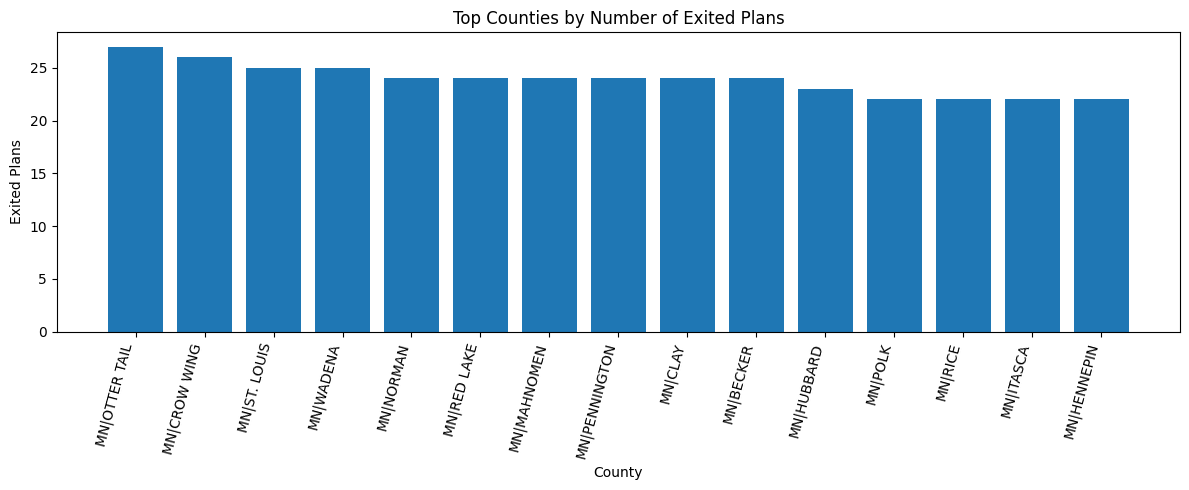

     state_key             county_id  exited_plans  exited_parent_orgs
540         MN         MN|OTTER TAIL            27                   4
502         MN          MN|CROW WING            26                   4
556         MN          MN|ST. LOUIS            25                   3
564         MN             MN|WADENA            25                   4
538         MN             MN|NORMAN            24                   4
547         MN           MN|RED LAKE            24                   4
527         MN           MN|MAHNOMEN            24                   4
541         MN         MN|PENNINGTON            24                   4
498         MN               MN|CLAY            24                   3
487         MN             MN|BECKER            24                   3
513         MN            MN|HUBBARD            23                   3
544         MN               MN|POLK            22                   4
550         MN               MN|RICE            22                   4
515   

In [ ]:
county_exit_plans = (
    df.groupby(["state_key", "county_id"], as_index=False)
      .agg(
          exited_plans=("plan_key", "nunique"),
          exited_parent_orgs=("parent_key", "nunique")
      )
      .sort_values("exited_plans", ascending=False)
)

top_counties = county_exit_plans.head(15).copy()

plt.figure(figsize=(12,5))
plt.bar(top_counties["county_id"], top_counties["exited_plans"])
plt.title("Top Counties by Number of Exited Plans")
plt.xlabel("County")
plt.ylabel("Exited Plans")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()
print(county_exit_plans.head(100))

****

**Calculate Parent Organizations by Number of Exited Plans and Generate a Chart**

In [ ]:
org_exit = (
    df.groupby("parent_key", as_index=False)
      .agg(
          exit_states=("state_key", "nunique"),
          exit_counties=("county_id", "nunique"),
          exited_plans=("plan_key", "nunique")
      )
      .sort_values(["exit_counties", "exited_plans"], ascending=False)
)

org_exit.head(20)

,parent_key,exit_states,exit_counties,exited_plans
17,HUMANA INC.,6,200,31
27,"MOLINA HEALTHCARE, INC.",1,133,2
41,"UNITEDHEALTH GROUP, INC.",10,131,67
19,LOUISIANA HEALTH SERVICE & INDEMNITY COMPANY,2,119,8
11,CVS HEALTH CORPORATION,20,116,111
37,THE CARLE FOUNDATION,4,103,15
40,UCARE MINNESOTA,2,90,21
16,"HEALTHPARTNERS, INC.",4,87,16
2,"AVIAN HEALTH HOLDINGS, LLC",1,84,12
4,BLUECROSS BLUESHIELD OF TENNESSEE,2,81,3


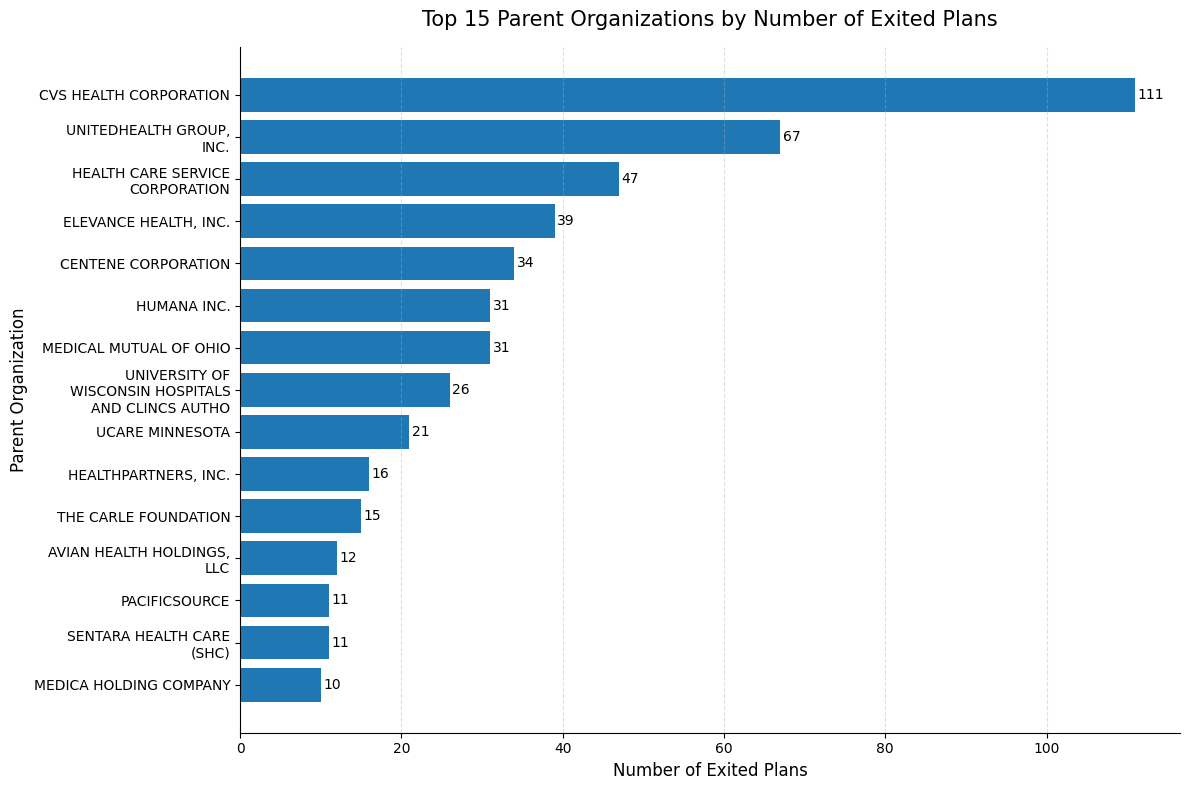

In [ ]:
import matplotlib.pyplot as plt
import textwrap

top_orgs = org_exit.sort_values("exited_plans", ascending=False).head(15).copy()
top_orgs = top_orgs.sort_values("exited_plans", ascending=True)

top_orgs["parent_label"] = top_orgs["parent_key"].apply(
    lambda x: "\n".join(textwrap.wrap(str(x), width=22))
)

plt.figure(figsize=(12, 8))
bars = plt.barh(top_orgs["parent_label"], top_orgs["exited_plans"])

plt.title("Top 15 Parent Organizations by Number of Exited Plans", fontsize=15, pad=15)
plt.xlabel("Number of Exited Plans", fontsize=12)
plt.ylabel("Parent Organization", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.4)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

**Calculate the 'plan type' feature of the exit plan and generate a chart**

In [ ]:
plan_type_dist = (
    df["plan_type_std"]
      .fillna("MISSING")
      .value_counts(dropna=False)
      .reset_index()
)
plan_type_dist.columns = ["plan_type", "count"]
plan_type_dist["share"] = plan_type_dist["count"] / plan_type_dist["count"].sum()
plan_type_dist

,plan_type,count,share
0,PPO,2295,0.287810
1,HMO-POS,1903,0.238651
2,HMO,1500,0.188111
3,HMO D-SNP,1126,0.141209
4,HMO C-SNP,321,0.040256
5,COST,284,0.035616
6,PPO D-SNP,213,0.026712
7,HMO-POS D-SNP,169,0.021194
8,HMO I-SNP,55,0.006897
9,PDP,33,0.004138


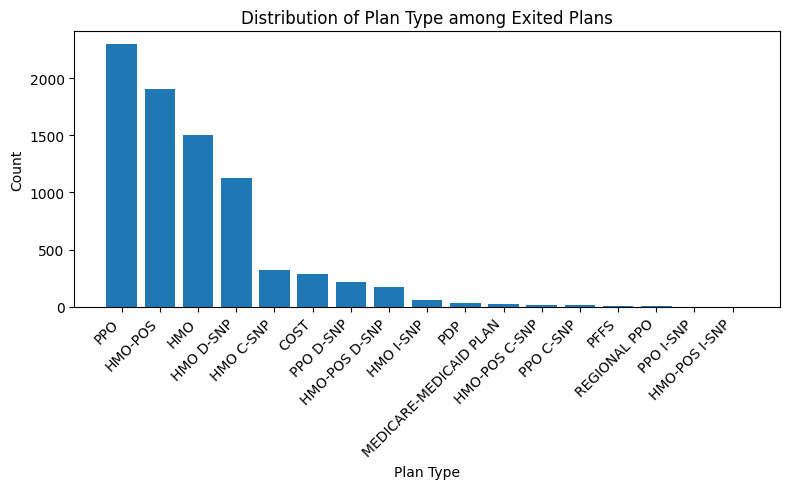

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(plan_type_dist["plan_type"], plan_type_dist["count"])
plt.title("Distribution of Plan Type among Exited Plans")
plt.xlabel("Plan Type")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Exit plan feature**

In [ ]:
county_plan_features = (
    df.groupby(["state_key", "county_id"], as_index=False)
      .agg(
          exited_plans=("county_plan_key", "nunique"),
          exited_parent_orgs=("parent_key", "nunique"),
          avg_premium=("premium_num", "mean"),
          median_premium=("premium_num", "median"),
          avg_moop=("moop_num", "mean"),
          median_moop=("moop_num", "median"),
          avg_star=("star_num", "mean"),
          median_star=("star_num", "median")
      )
      .sort_values("exited_plans", ascending=False)
)

county_plan_features.head(20)

,state_key,county_id,exited_plans,exited_parent_orgs,avg_premium,median_premium,avg_moop,median_moop,avg_star,median_star
540,MN,MN|OTTER TAIL,27,4,11.681481,0.0,5594.444444,5000.0,3.740741,4.00
502,MN,MN|CROW WING,26,4,17.107692,0.0,5436.538462,4950.0,3.826923,4.00
556,MN,MN|ST. LOUIS,25,3,21.612000,0.0,5360.000000,4900.0,3.780000,3.50
564,MN,MN|WADENA,25,4,10.188000,0.0,5612.000000,5200.0,3.760000,4.00
538,MN,MN|NORMAN,24,4,12.516667,0.0,5556.250000,5200.0,3.729167,3.75
547,MN,MN|RED LAKE,24,4,12.516667,0.0,5556.250000,5200.0,3.729167,3.75
527,MN,MN|MAHNOMEN,24,4,12.516667,0.0,5556.250000,5200.0,3.729167,3.75
541,MN,MN|PENNINGTON,24,4,12.516667,0.0,5556.250000,5200.0,3.729167,3.75
498,MN,MN|CLAY,24,3,22.512500,0.0,5400.000000,4900.0,3.750000,3.50
487,MN,MN|BECKER,24,3,22.512500,0.0,5400.000000,4900.0,3.750000,3.50


In [ ]:
summary_table = pd.DataFrame({
    "Metric": [
        "Total records",
        "Unique states",
        "Unique counties",
        "Unique parent organizations",
        "Unique carrier-county exit events",
        "Unique exited plans"
    ],
    "Value": [7974, 43, 1268, 45, 1644, 607]
})

summary_table

,Metric,Value
0,Total records,7974
1,Unique states,43
2,Unique counties,1268
3,Unique parent organizations,45
4,Unique carrier-county exit events,1644
5,Unique exited plans,607
